# Targeted subgroup analysis: readers subgroup

1. Cleaning/ validation steps
2. Overall response distribution
3. Counts and proportions by condition
    - Goal Type
    - Agency
    - Goal Type x Agency

Import libraries

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Read data

In [60]:
merged_data = pd.read_csv("../../data/processed/merged_clean.csv")

## 1. Cleaning/ validation steps

Subset data for subgroup: 

- Proficiency: Per_Level_Label = ["B2.1", "B2.2", "C1"]
- Exposure: Prof_Use_Label = "Yes"

In [61]:
subgroup = merged_data[
    (merged_data["Per_Level_Label"].isin(["B2.1", "B2.2", "C1"])
    ) & (merged_data["Prof_Use_Label"] == "Yes")      
]

Subgroup validation

In [62]:
subgroup.shape

(198, 31)

In [63]:
subgroup.columns

Index(['Participant_ID', 'Focus', 'Agent', 'Goal_Type', 'Item', 'Item_string',
       'Item_len', 'Response_tag', 'Response', 'Response_Full', 'EXP', 'n',
       'Age', 'Gender', 'Kno_Level', 'Per_Level', 'Bilingual', 'Bi_Parents',
       'Multi_Kno', 'Multi_Spk', 'Immersion', 'Prof_Need', 'Prof_Use',
       'Motivation', 'Distractor', 'GN_Score', 'Difficulty', 'Kno_Level_Label',
       'Per_Level_Label', 'Prof_Need_Label', 'Prof_Use_Label'],
      dtype='str')

In [64]:
subgroup.duplicated().sum()

np.int64(0)

In [65]:
subgroup.head()

,Participant_ID,Focus,Agent,Goal_Type,Item,Item_string,Item_len,Response_tag,Response,Response_Full,...,Prof_Need,Prof_Use,Motivation,Distractor,GN_Score,Difficulty,Kno_Level_Label,Per_Level_Label,Prof_Need_Label,Prof_Use_Label
0,EXP1_01,I,1,no_goal,Item1,"""If I had heard the rainstorm, I would have fe...",11,L1_transfer_3,L1_transfer,L1_transfer,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
1,EXP1_01,I,1,no_goal,Item2,"""If I had climbed the mountain cliff, I would ...",12,L1_transfer_3,L1_transfer,L1_transfer,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
2,EXP1_01,I,1,goal_non_frequent,Item1,"""If I had created an online platform, I would ...",14,L1_transfer_3,L1_transfer,L1_transfer,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
3,EXP1_01,I,1,goal_non_frequent,Item2,"""If I had invested in technology, I would have...",13,correct_3,correct,correct,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
4,EXP1_01,I,1,goal_frequent,Item1,"""If I had saved money, I would have gone on ho...",11,correct_3,correct,correct,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes


Slice data by focus: "readers" or "other-focus"

In [66]:
subgroup_readers = subgroup[subgroup["Focus"] == "They"].copy()

## 2. Overall response distribution for Readers

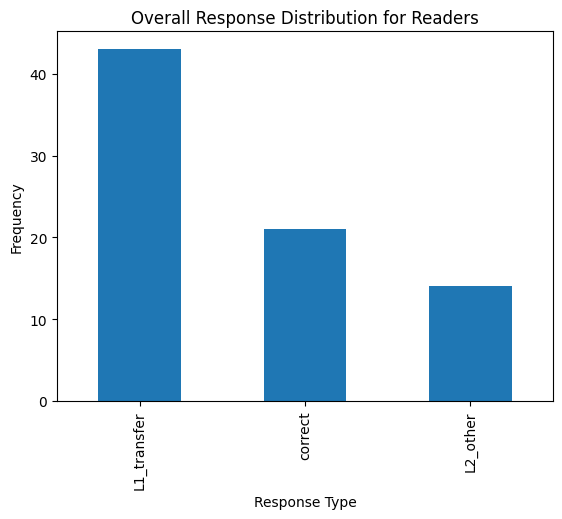

In [67]:
subgroup_readers["Response_Full"].value_counts().plot(kind="bar")

plt.title("Overall Response Distribution for Readers") 
plt.xlabel("Response Type") 
plt.ylabel("Frequency")
plt.show()

Once again, the readers subgroup keeps backss up for an increase in transfer responses providing support to its dominance shown in the general group visual EDA before slicing. 

## 3. Counts and proportions by condition

**Responses by Goal Type for readers:**

- Counts
- Proportions 
- Proportions plot

In [85]:
goal_response_counts_r = pd.crosstab(
    subgroup_readers["Goal_Type"],
    subgroup_readers["Response_Full"],
    dropna= False,
    margins= True
)

goal_response_counts_r

Response_Full,L1_transfer,L2_other,correct,All
Goal_Type,,,,
goal_frequent,12,6,8,26
goal_non_frequent,19,1,6,26
no_goal,12,7,7,26
All,43,14,21,78


In [86]:
goal_response_props_r = pd.crosstab(
    subgroup_readers["Goal_Type"],
    subgroup_readers["Response_Full"],
    dropna=False,
    normalize= "index"
)

goal_response_props_r

Response_Full,L1_transfer,L2_other,correct
Goal_Type,,,
goal_frequent,0.461538,0.230769,0.307692
goal_non_frequent,0.730769,0.038462,0.230769
no_goal,0.461538,0.269231,0.269231


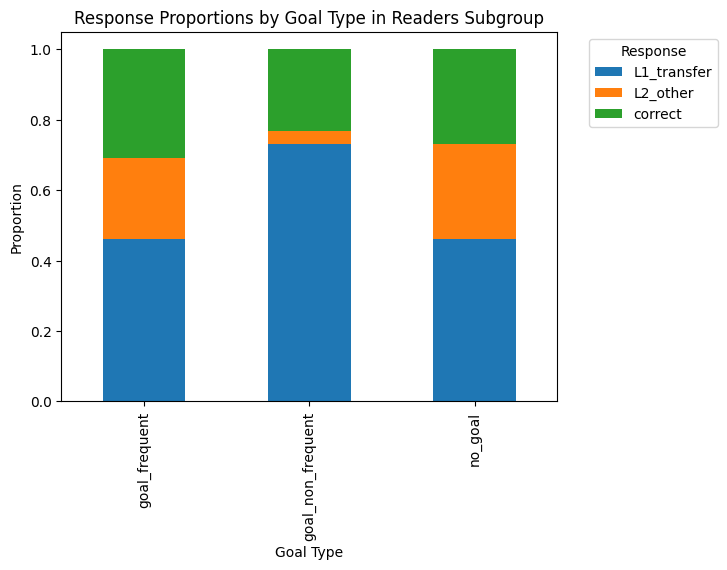

In [87]:
goal_response_props_r.plot(kind = "bar", stacked = True)

plt.title("Response Proportions by Goal Type in Readers Subgroup")
plt.xlabel("Goal Type")
plt.ylabel("Proportion")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

- goal_frequent keeps being the goal type that favors most correct responses proportion (almost 0.31) in readers although less than in actors (0.40).

- Reeaching 0.73 for the non_frequent goal condtions together with the drop in L2-alternatives (0.03) shows that participants are not hesitating; they are resolving by transfer. Distancing from a self-perspective could be hindering correct restructuring. 

- Transfer resolution distribution was the highgest for no_goals in actors (0.55); here, it seems to decrease to almost 0.46 in favor of L2 alternatives, that went from 0.12 to almost 0.27 while correct responses remain roughly the same. So there is room for hesitation and finding alternatives for readers that doesn't not show in actors even if they don't get to resolve correctly.

**Responses by Agent for readers:**

- Counts
- Proportions 
- Proportions plot

In [88]:
agent_response_counts_r = pd.crosstab(
    subgroup_readers["Agent"],
    subgroup_readers["Response_Full"],
    dropna= False, 
    margins= True
)

agent_response_counts_r

Response_Full,L1_transfer,L2_other,correct,All
Agent,,,,
0,31,12,11,54
1,12,2,10,24
All,43,14,21,78


In [89]:
agent_response_props_r = pd.crosstab(
    subgroup_readers["Agent"],
    subgroup_readers["Response_Full"],
    dropna= False,
    normalize="index"
)

agent_response_props_r

Response_Full,L1_transfer,L2_other,correct
Agent,,,
0,0.574074,0.222222,0.203704
1,0.500000,0.083333,0.416667


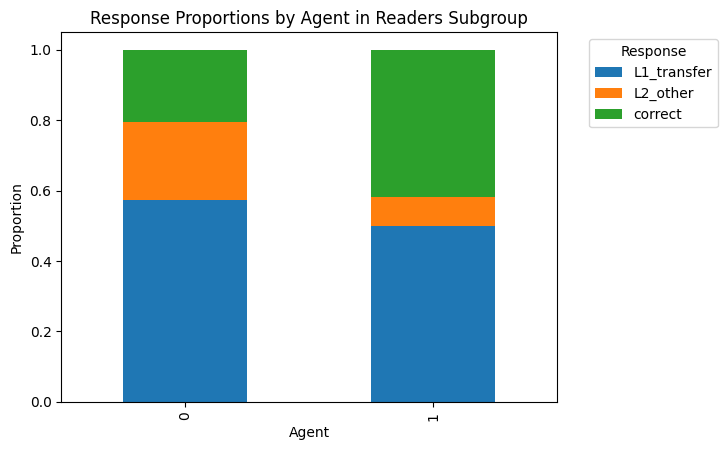

In [90]:
agent_response_props_r.plot(kind="bar", stacked=True)

plt.title("Response Proportions by Agent in Readers Subgroup")
plt.xlabel("Agent")
plt.ylabel("Proportion")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

- Just as with actors, L2-alternatives almost dissapear once the agent comes into play, and competition shows between resolving with either correct restructuring or transfer. 

- Now, the distribution of correct responses was actually pretty even for actors with or without an explicit agent while having the explicit agent favored transfer resolution; for readers, not only does explicit agency decrease transfer resolution but it actually favors correctness.  So, perhaps accountability could be leading to overload and transfer resolution while being detached or having an external anchor could actually be benefitial.

**Responses by Goal Type and Agent for readers:**

- Counts
- Proportions 
- Proportions plot

In [91]:
goal_agent_response_counts_r = pd.crosstab(
    [subgroup_readers["Goal_Type"], subgroup_readers["Agent"]],
    subgroup_readers["Response_Full"],
    dropna= False,
    margins= True
)

goal_agent_response_counts_r

Response_Full            L1_transfer  L2_other  correct  All
Goal_Type         Agent                                     
goal_frequent     0                7         6        5   18
                  1                5         0        3    8
goal_non_frequent 0               14         1        3   18
                  1                5         0        3    8
no_goal           0               10         5        3   18
                  1                2         2        4    8
All                               43        14       21   78

In [92]:
goal_agent_response_props_r = pd.crosstab(
    [subgroup_readers["Goal_Type"], subgroup_readers["Agent"]],
    subgroup_readers["Response_Full"],
    dropna= False,
    normalize="index"
)

goal_agent_response_props_r

Response_Full            L1_transfer  L2_other   correct
Goal_Type         Agent                                 
goal_frequent     0         0.388889  0.333333  0.277778
                  1         0.625000  0.000000  0.375000
goal_non_frequent 0         0.777778  0.055556  0.166667
                  1         0.625000  0.000000  0.375000
no_goal           0         0.555556  0.277778  0.166667
                  1         0.250000  0.250000  0.500000

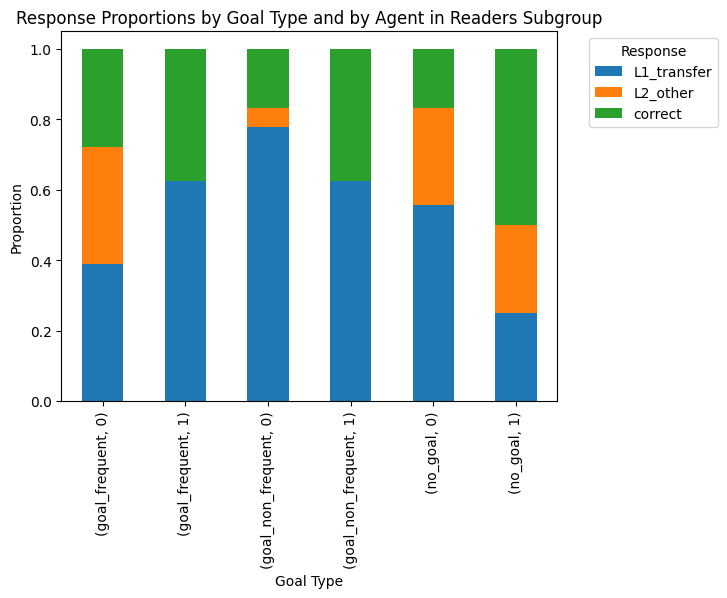

In [93]:
goal_agent_response_props_r.plot(kind="bar", stacked= True)

plt.title("Response Proportions by Goal Type and by Agent in Readers Subgroup")
plt.xlabel("Goal Type")
plt.ylabel("Proportion")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

- As expected, transfer responses increased heavily in most of the conditions (but for no_goal, agent =1) but, particulary, it affected conditions in which there is lack of explicit agency compared to actors. Correct responses distribution without agency is also lower compared to actors. 

- What explicit agency favors seems to be correct resolution. So, self-focus perspective could help be intensifying competition while other-focuse perspective could help stabilizing the process.

- No_goal, again, performs very differently when compared to the other 2 type of goals save for the fact that correctness increase with explicit agency. In fact, 0.50 of observations are correct and transfer responses are the lowest of all conditions (0.25). This is also very different to the actors behaviour in which, both no_goal conditions looked pretty much the same with or without explicit agency with a very high proportion of transfer resolution -both > 0.50. So, no_goal and explicit agency, for readers, not only is it the condition that favors the most correct responses while keeping the same distribution of L2-alternatives, but is also does so at the expense of transfer responses compared to its agent = 0 counterpart. 

- This could be a case in which agency interacts with perspective; however, by this stage and given the changes in distributions, there might not be enough readers observations to account for statistical differences. There could be a pattern to show, but not enough to attempt statistical significance.